# Financial Sentiment Analysis — QLoRA + Pinecone RAG
**Model**: LLaMA-2-7B | **Technique**: QLoRA | **Dataset**: Financial Phrasebank

Run cells in order from top to bottom.

## Cell 1 — Mount Google Drive

In [1]:
!git -C /content/financial-llm-sentiment pull

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 413 bytes | 413.00 KiB/s, done.
From https://github.com/vkquanghd/financial-llm-sentiment
   c1e4637..540158d  main       -> origin/main
Updating c1e4637..540158d
Fast-forward
 model/train.py | 2 +-
 1 file changed, 1 insertion(+), 1 deletion(-)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/financial-llm/saved_model', exist_ok=True)
os.makedirs('/content/drive/MyDrive/financial-llm/checkpoints', exist_ok=True)
os.makedirs('/content/drive/MyDrive/financial-llm/logs', exist_ok=True)
os.makedirs('/content/drive/MyDrive/financial-llm/cache', exist_ok=True)

print('Drive mounted and folders created.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted and folders created.


## Cell 2 — Set API Keys (from Colab Secrets)

In [3]:
# Add your keys in Colab: left sidebar → 🔑 Secrets
# Keys needed: PINECONE_API_KEY, HF_TOKEN

from google.colab import userdata
import os

os.environ['PINECONE_API_KEY'] = userdata.get('PINECONE_API_KEY')
os.environ['HF_TOKEN']         = userdata.get('HF_TOKEN')

# Cache HuggingFace datasets to Drive so we don't re-download each session
os.environ['HF_DATASETS_CACHE'] = '/content/drive/MyDrive/financial-llm/cache'

print('API keys loaded.')

API keys loaded.


## Cell 3 — Clone Repo + Install Dependencies

In [4]:
import os

REPO_URL = 'https://github.com/vkquanghd/financial-llm-sentiment.git'
REPO_DIR = '/content/financial-llm-sentiment'

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    !git -C {REPO_DIR} pull

%cd {REPO_DIR}

for folder in ['data', 'model', 'rag', 'app']:
    open(f'{folder}/__init__.py', 'w').close()
    print(f'✅ {folder}/__init__.py')

!pip install -q -r requirements.txt
print('Setup complete.')

import sys
if '/content/financial-llm-sentiment' not in sys.path:
    sys.path.insert(0, '/content/financial-llm-sentiment')
print('sys.path updated.')

Already up to date.
/content/financial-llm-sentiment
✅ data/__init__.py
✅ model/__init__.py
✅ rag/__init__.py
✅ app/__init__.py
Setup complete.
sys.path updated.


## Cell 4 — Check GPU

In [5]:
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU  : {gpu_name}')
    print(f'VRAM : {vram_gb:.1f} GB')
    print(f'BF16 : {torch.cuda.is_bf16_supported()}')
else:
    print('No GPU detected. Go to Runtime → Change runtime type → GPU (A100).')

GPU  : NVIDIA A100-SXM4-40GB
VRAM : 42.4 GB
BF16 : True


## Cell 5 — Prepare Data (preview)

In [6]:
import os
os.chdir('/content/financial-llm-sentiment')

for folder in ['data', 'model', 'rag', 'app']:
    open(f'{folder}/__init__.py', 'w').close()

print('Done.')

Done.


## Cell 6 — Train Model

In [7]:
import sys
import importlib

# Remove cached failed imports
for key in list(sys.modules.keys()):
    if 'model' in key or 'data' in key or 'rag' in key or 'app' in key:
        del sys.modules[key]

# Try import again
from model.train import train
print('Import successful!')

Import successful!


In [8]:
import sys
sys.path.insert(0, '/content/financial-llm-sentiment')

from model.train import train

trainer, tokenizer, rag_sentences = train()

  Financial Sentiment — QLoRA Fine-Tuning

[Step 1/5] Preparing dataset...
[Data] Loading twitter-financial-news-sentiment...
[Data] Total samples: 9543
[Data] Columns: ['text', 'label']
[Data] Label distribution:
         bearish    (label=0): 1442 samples (15.1%)
         bullish    (label=1): 1923 samples (20.2%)
         neutral    (label=2): 6178 samples (64.7%)
[Data] Splitting: 80% train / 10% val / 10% test...
[Data] Train: 7634 | Val: 954 | Test: 955
[Tokenizer] Loading from: meta-llama/Llama-2-7b-hf
[Tokenizer] Vocab size:   32000
[Tokenizer] pad_token:    </s> (id=2)
[Data] Tokenizing dataset...
[Data] Done. Sample keys: ['label', 'input_ids', 'attention_mask', 'labels']
[RAG] Extracted 9543 sentences for Pinecone indexing.

[Step 2/5] Loading base model...
[Model] Loading meta-llama/Llama-2-7b-hf with 4-bit quantization...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] LlamaForSequenceClassification LOAD REPORT from: meta-llama/Llama-2-7b-hf
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


[Model] Base model loaded. Total parameters: 6,607,355,904

[Step 3/5] Applying LoRA adapters...
[LoRA] Trainable parameters: 4,206,592 / 6,611,562,496 (0.064%)

[Step 4/5] Starting training...


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.748679,0.297277,0.885700,0.842800
2,0.451904,0.236381,0.906700,0.880200
3,0.276725,0.226214,0.918200,0.896100



[Step 5/5] Evaluating on test set...


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.276725,0.270409,3,0.907900,0.876800



[Results] Test Accuracy : 0.9079
[Results] Test F1 Macro : 0.8768
[Results] Test Loss     : 0.2704
[Save] Saving model to: /content/drive/MyDrive/financial-llm/saved_model
[Save] Model saved successfully.

[Done] Training complete.


## Cell 7 — Index Financial Sentences into Pinecone

In [11]:
from rag.pinecone_utils import initialize_rag

# rag_sentences came from train() — reuse without reloading data
index, embed_model = initialize_rag(rag_sentences)

print(f'Pinecone index stats: {index.describe_index_stats()}')

[Pinecone] Connected successfully.
[Pinecone] Index 'financial-sentiment' already exists. Skipping creation.
[Embedding] Loading model: sentence-transformers/all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/content/financial-llm-sentiment/rag/pinecone_utils.py:82: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"[Embedding] Model loaded. Output dimension: {model.get_sentence_embedding_dimension()}")


[Embedding] Model loaded. Output dimension: 384
[Pinecone] Embedding 9543 documents...


Batches:   0%|          | 0/299 [00:00<?, ?it/s]

[Pinecone] Upserted batch 1/96 (100 vectors)
[Pinecone] Upserted batch 2/96 (100 vectors)
[Pinecone] Upserted batch 3/96 (100 vectors)
[Pinecone] Upserted batch 4/96 (100 vectors)
[Pinecone] Upserted batch 5/96 (100 vectors)
[Pinecone] Upserted batch 6/96 (100 vectors)
[Pinecone] Upserted batch 7/96 (100 vectors)
[Pinecone] Upserted batch 8/96 (100 vectors)
[Pinecone] Upserted batch 9/96 (100 vectors)
[Pinecone] Upserted batch 10/96 (100 vectors)
[Pinecone] Upserted batch 11/96 (100 vectors)
[Pinecone] Upserted batch 12/96 (100 vectors)
[Pinecone] Upserted batch 13/96 (100 vectors)
[Pinecone] Upserted batch 14/96 (100 vectors)
[Pinecone] Upserted batch 15/96 (100 vectors)
[Pinecone] Upserted batch 16/96 (100 vectors)
[Pinecone] Upserted batch 17/96 (100 vectors)
[Pinecone] Upserted batch 18/96 (100 vectors)
[Pinecone] Upserted batch 19/96 (100 vectors)
[Pinecone] Upserted batch 20/96 (100 vectors)
[Pinecone] Upserted batch 21/96 (100 vectors)
[Pinecone] Upserted batch 22/96 (100 vector

## Cell 8 — Test Inference

In [66]:
from model.inference import predict_sentiment, predict_with_rag

test_sentences = [
    'The company reported record profits this quarter.',
    'Markets remained flat amid economic uncertainty.',
    'Stock prices collapsed after the earnings miss.',
]

print('=== Without RAG ===')
for s in test_sentences:
    result = predict_sentiment(s, trainer.model, tokenizer)
    print(f'  [{result["label"].upper():8s}] {s}')

print('\n=== With RAG ===')
for s in test_sentences:
    result = predict_with_rag(s, trainer.model, tokenizer, index, embed_model)
    print(f'  [{result["label"].upper():8s}] {s}')
    print(f'  Context: {result["retrieved_context"][0][:80]}...')

=== Without RAG ===
  [NEUTRAL ] The company reported record profits this quarter.
  [NEUTRAL ] Markets remained flat amid economic uncertainty.
  [NEUTRAL ] Stock prices collapsed after the earnings miss.

=== With RAG ===
[Retriever] Query: 'The company reported record profits this quarter.'
[Retriever] Retrieved 3 context chunks.
  [NEUTRAL ] The company reported record profits this quarter.
  Context: Deluxe Reports Fourth Quarter 2019 Results and Record Full Year Revenue...
[Retriever] Query: 'Markets remained flat amid economic uncertainty.'
[Retriever] Retrieved 3 context chunks.
  [NEUTRAL ] Markets remained flat amid economic uncertainty.
  Context: Gold Prices Near Flat Despite Uncertainties Revolving Around Prolonged Trade Spa...
[Retriever] Query: 'Stock prices collapsed after the earnings miss.'
[Retriever] Retrieved 3 context chunks.
  [BEARISH ] Stock prices collapsed after the earnings miss.
  Context: Stocks close mostly lower on earnings concerns...


## Cell 9 — Evaluate on Test Set

[Data] Loading twitter-financial-news-sentiment...
[Data] Total samples: 9543
[Data] Columns: ['text', 'label']
[Data] Label distribution:
         bearish    (label=0): 1442 samples (15.1%)
         bullish    (label=1): 1923 samples (20.2%)
         neutral    (label=2): 6178 samples (64.7%)
[Data] Splitting: 80% train / 10% val / 10% test...
[Data] Train: 7634 | Val: 954 | Test: 955
[Tokenizer] Loading from: meta-llama/Llama-2-7b-hf
[Tokenizer] Vocab size:   32000
[Tokenizer] pad_token:    </s> (id=2)
[Data] Tokenizing dataset...
[Data] Done. Sample keys: ['label', 'input_ids', 'attention_mask', 'labels']
[RAG] Extracted 9543 sentences for Pinecone indexing.

[Evaluation] Test Set Results:
  accuracy    : 0.9079
  f1_macro    : 0.8768
  precision   : 0.8815
  recall      : 0.8725

[Evaluation] Classification Report:
              precision    recall  f1-score   support

     bearish       0.83      0.79      0.81       121
     bullish       0.88      0.89      0.88       212
     n

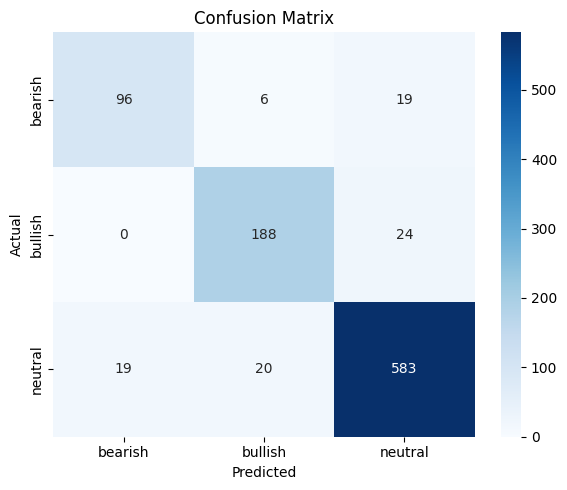

[Evaluate] Confusion matrix saved to: /content/drive/MyDrive/financial-llm/saved_model/confusion_matrix.png


In [67]:
from data.prepare_data import prepare_dataset
from model.evaluate import evaluate_on_testset

tokenized_dataset, _, _ = prepare_dataset()
results = evaluate_on_testset(trainer.model, tokenizer, tokenized_dataset['test'])

## Cell 10 — Attention Heatmap

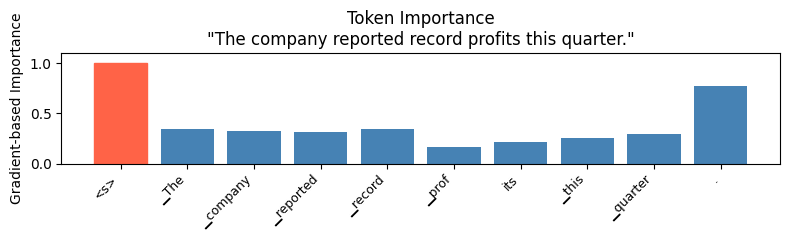

[Evaluate] Token importance chart saved to: /content/drive/MyDrive/financial-llm/saved_model/attention_heatmap.png


In [25]:

import importlib
import model.evaluate
importlib.reload(model.evaluate)
from model.evaluate import plot_attention_heatmap

plot_attention_heatmap(
    sentence  = 'The company reported record profits this quarter.',
    model     = trainer.model,
    tokenizer = tokenizer,
)

## Cell 11 — Benchmark Table

In [22]:
from model.evaluate import build_benchmark_table

# Fill in the numbers after running each model
benchmark_results = {
    'BERT-base':   {'params_M': 110,  'time_min': 15, 'memory_gb': 2.1, 'f1': 0.0, 'accuracy': 0.0},
    'LLaMA-QLoRA': {'params_M': 7000, 'time_min': 45, 'memory_gb': 5.2, 'f1': results['f1_macro'], 'accuracy': results['accuracy']},
}

df = build_benchmark_table(benchmark_results)


[Benchmark] Model Comparison:
      Model  Params (M)  Train Time (min)  Memory (GB)  F1 Macro  Accuracy
  BERT-base       110.0              15.0          2.1    0.0000    0.0000
LLaMA-QLoRA      7000.0              45.0          5.2    0.8768    0.9079
[Benchmark] Table saved to: /content/drive/MyDrive/financial-llm/saved_model/benchmark.csv


## Cell 12 — Launch Gradio App

In [65]:
# import importlib
# import app.gradio_app as app_module
# importlib.reload(app_module)
# from app.gradio_app import build_app

# app_module.model       = trainer.model
# app_module.tokenizer   = tokenizer
# app_module.index       = index
# app_module.embed_model = embed_model

# gradio_app = build_app()
# gradio_app.launch(share=True)